In [4]:
# for colab
try:
    import google.colab

    !curl -LsSf https://astral.sh/uv/install.sh | sh
    !git clone https://github.com/stanfish06/micropattern.git /tmp/micropattern
    !cp -r /tmp/micropattern/. .
    !rm -rf /tmp/micropattern
    !pip install -e .
    import sys

    sys.path.insert(0, "/content/src")

    # remember to upload aws credentials
    !mkdir -p ~/.aws
    !cp /content/credentials ~/.aws
    !ls ~/.aws
except ImportError:
    raise RuntimeError(
        "make sure to connect to colab kernel or code above will wipe locally"
    )

downloading uv 0.10.2 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
Cloning into '/tmp/micropattern'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (186/186), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 186 (delta 105), reused 133 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (186/186), 7.06 MiB | 39.10 MiB/s, done.
Resolving deltas: 100% (105/105), done.
Obtaining file:///content
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for micropattern (pyproject.toml) ... done
  Created wheel for micropattern: filename=micropattern-0.1.0-py3-none-any.whl size=1315 sha256=95c01b6f184d6137f84c4f5554389239f0a04aaf1e07a084f400ad5e745b110c
  Stored in directory: /tmp/pip-ephem-wheel-cache-s

In [2]:
!ps aux --sort=-%mem | head -20

USER         PID %CPU %MEM    VSZ   RSS TTY      STAT START   TIME COMMAND
root         126  1.8  0.2 655604 152220 ?       Sl   01:51   0:04 /usr/bin/python3 /usr/local/bin/jupyter-server --debug --transport="ipc" --ip=172.28.0.12 --ServerApp.token= --port=9000 --FileContentsManager.root_dir=/ --FileContentsManager.allow_hidden=True --ServerApp.log_format="|%(levelname)s|%(message)s" --ServerApp.iopub_data_rate_limit=1e10 --MappingKernelManager.root_dir=/content
root         998 10.8  0.2 928428 122688 ?       Ssl  01:54   0:04 /usr/bin/python3 -m colab_kernel_launcher -f /root/.local/share/jupyter/runtime/kernel-49fd65fd-ce3e-481f-a5ba-1e3ee70d2576.json
root          79  0.7  0.1  99412 75796 ?        S    01:51   0:01 python3 /usr/local/bin/colab-fileshim.py
root           7  0.2  0.1 1095780 59100 ?       Sl   01:51   0:00 /tools/node/bin/node /datalab/web/app.js
root          12  0.0  0.0 1272856 17364 ?       Sl   01:51   0:00 /usr/colab/bin/kernel_manager_proxy --listen_port=600

In [ ]:
!kill

In [6]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            50Gi       1.3Gi        44Gi       3.0Mi       4.8Gi        49Gi
Swap:             0B          0B          0B


In [5]:
!nvidia-smi

Sat Feb 14 01:55:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
import micropattern as mic
from pathlib import Path
import scprep
import scanpy as sc
import pandas as pd

cwd = Path(".").resolve()
print(cwd)

/content


# Data download and prep

In [5]:
mic.io.fetch_minn(cwd, type="mtx")

100%|██████████| 1/1 [00:00<00:00, 12.37it/s]


100%|██████████| 1/1 [00:00<00:00,  4.19it/s]


100%|██████████| 1/1 [00:00<00:00,  1.18it/s]


100%|██████████| 1/1 [00:00<00:00, 12.26it/s]


100%|██████████| 1/1 [00:00<00:00,  8.81it/s]


...

100%|██████████| 1/1 [00:00<00:00,  7.88it/s]


100%|██████████| 1/1 [00:01<00:00,  1.61s/it]


100%|██████████| 1/1 [00:00<00:00, 10.84it/s]


100%|██████████| 1/1 [00:00<00:00,  7.87it/s]


100%|██████████| 1/1 [00:00<00:00,  1.75it/s]


In [9]:
sample_list_0_24h = []
for f in (cwd / "minn_data").glob("*.matrix.tsv.gz"):
    if f.is_file():
        sample_list_0_24h.append(f.name.split(".")[0])
sample_list_0_24h = list(set(sample_list_0_24h))
sample_list_0_24h.sort()
print(sample_list_0_24h)

sample_list_44h = []
for f in (cwd / "minn_data").glob("*.matrix.mtx.gz"):
    if f.is_file():
        sample_list_44h.append(f.name.split(".")[0])
sample_list_44h = list(set(sample_list_44h))
sample_list_44h.sort()
print(sample_list_44h)

['GSM5176718_gastruloid_0h_1', 'GSM5176719_gastruloid_0h_2', 'GSM5176720_gastruloid_12h_1', 'GSM5176721_gastruloid_12h_2', 'GSM5176722_gastruloid_24h_1', 'GSM5176723_gastruloid_24h_2']
['GSM4300502_gastruloid1', 'GSM4300503_gastruloid2']


In [20]:
data_path = cwd / "minn_data"
data_list = {}
for s in sample_list_0_24h:
    print(s)
    dat = scprep.io.load_mtx(
        data_path / f"{s}.matrix.tsv.gz",
        cell_axis="column",
        gene_names=str(data_path / f"{s}.genes.tsv.gz"),
        cell_names=str(data_path / f"{s}.barcodes.tsv.gz"),
        sparse=True,
    )
    dat.columns = dat.columns.str.replace("\t", " ")
    dat.columns = dat.columns.str.replace(" Gene Expression", "")
    dat.columns = pd.Index(
        [g if len(g) == 1 else f"{g[1]} ({g[0]})" for g in dat.columns.str.split(" ")]
    )
    data_list[s] = dat

for s in sample_list_44h:
    print(s)
    dat = scprep.io.load_mtx(
        data_path / f"{s}.matrix.mtx.gz",
        cell_axis="column",
        gene_names=str(data_path / f"{s}.genes.tsv.gz"),
        cell_names=str(data_path / f"{s}.barcodes.tsv.gz"),
        sparse=True,
    )
    dat.columns = dat.columns.str.replace("\t", " ")
    dat.columns = pd.Index(
        [g if len(g) == 1 else f"{g[1]} ({g[0]})" for g in dat.columns.str.split(" ")]
    )
    data_list[f"{s}_44h"] = dat

GSM5176718_gastruloid_0h_1
GSM5176719_gastruloid_0h_2
GSM5176720_gastruloid_12h_1
GSM5176721_gastruloid_12h_2
GSM5176722_gastruloid_24h_1
GSM5176723_gastruloid_24h_2
GSM4300502_gastruloid1
GSM4300503_gastruloid2


# QC

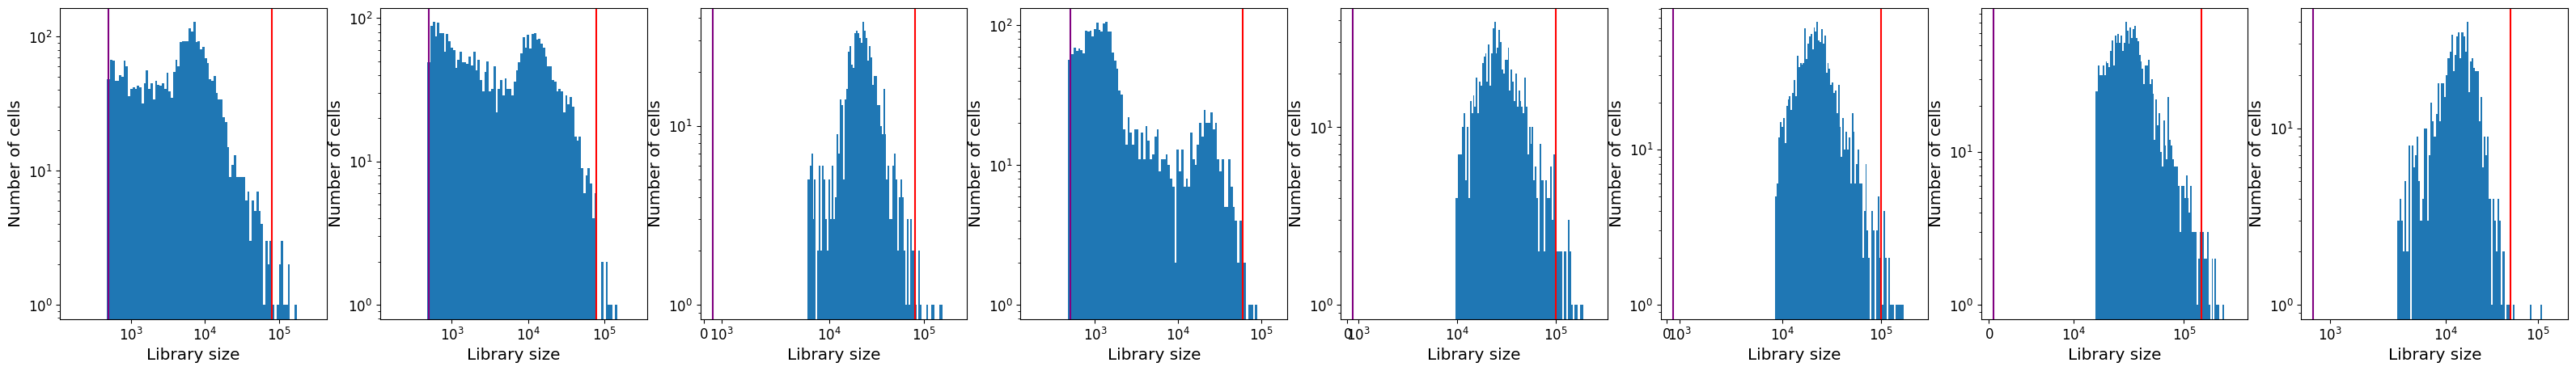

In [21]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(1, len(data_list), figsize=(5 * len(data_list), 5))
thresholds = [
    (500, 8e4),
    (500, 8e4),
    (500, 8e4),
    (500, 6e4),
    (500, 1e5),
    (500, 1e5),
    (500, 1.5e5),
    (500, 0.5e5),
]
for (s, dat), (ax, th) in zip(data_list.items(), zip(axes, thresholds)):
    scprep.plot.plot_library_size(dat, ax=ax)
    ax.axvline(th[1], color="red")
    ax.axvline(th[0], color="purple")

before lib filtGSM5176718_gastruloid_0h_1: (3183, 32738)
after lib filt GSM5176718_gastruloid_0h_1: (3169, 32738)
after gene filt GSM5176718_gastruloid_0h_1: (3169, 16383)
before lib filtGSM5176719_gastruloid_0h_2: (3381, 32738)
after lib filt GSM5176719_gastruloid_0h_2: (3373, 32738)
after gene filt GSM5176719_gastruloid_0h_2: (3373, 17785)
before lib filtGSM5176720_gastruloid_12h_1: (784, 33694)
after lib filt GSM5176720_gastruloid_12h_1: (774, 33694)
after gene filt GSM5176720_gastruloid_12h_1: (774, 15087)
before lib filtGSM5176721_gastruloid_12h_2: (2492, 32738)
after lib filt GSM5176721_gastruloid_12h_2: (2484, 32738)
after gene filt GSM5176721_gastruloid_12h_2: (2484, 14852)
before lib filtGSM5176722_gastruloid_24h_1: (975, 33694)
after lib filt GSM5176722_gastruloid_24h_1: (951, 33694)
after gene filt GSM5176722_gastruloid_24h_1: (951, 15548)
before lib filtGSM5176723_gastruloid_24h_2: (1608, 33694)
after lib filt GSM5176723_gastruloid_24h_2: (1590, 33694)
after gene filt GSM51

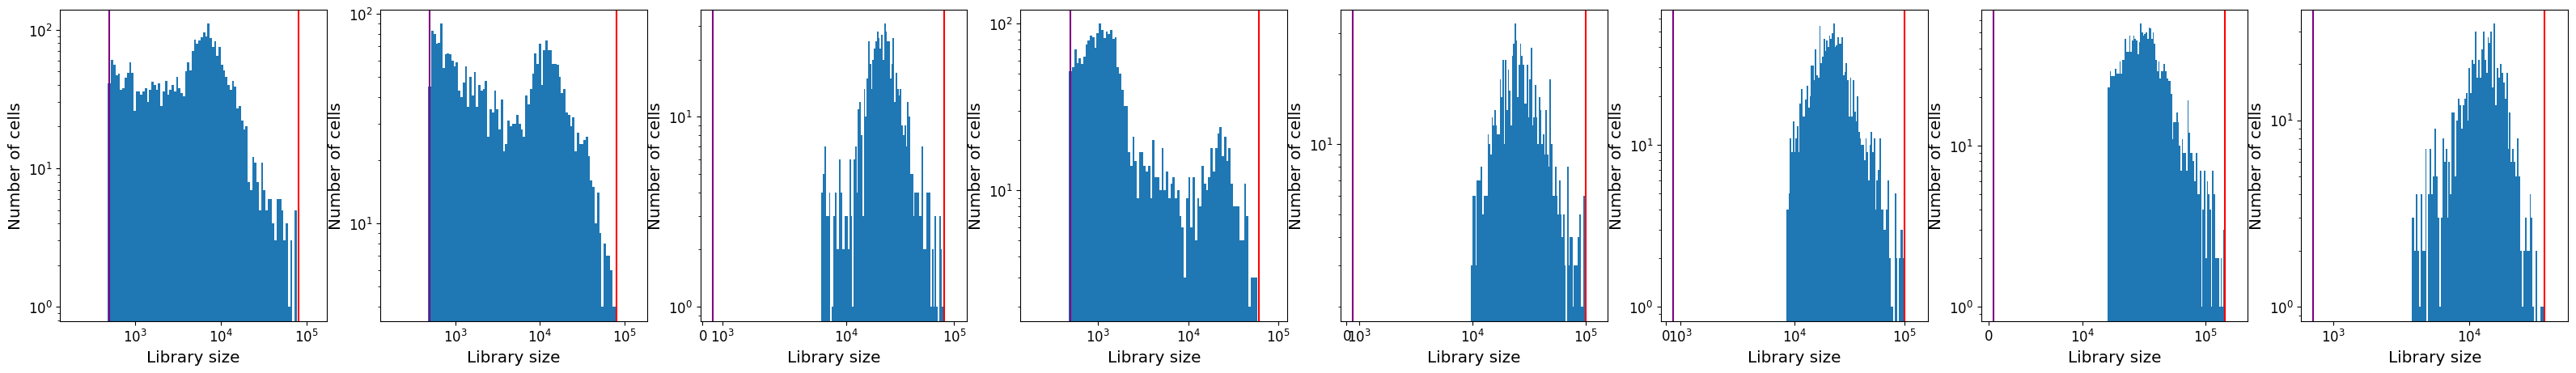

In [22]:
data_list_filt = {}
for (s, dat), th in zip(data_list.items(), thresholds):
    print(f"before lib filt{s}: {dat.shape}")
    dat = scprep.filter.filter_library_size(data=dat, cutoff=th)
    print(f"after lib filt {s}: {dat.shape}")
    dat = scprep.filter.remove_rare_genes(dat, cutoff=0, min_cells=5)
    print(f"after gene filt {s}: {dat.shape}")
    data_list_filt[s] = dat

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), (ax, th) in zip(data_list_filt.items(), zip(axes, thresholds)):
    scprep.plot.plot_library_size(dat, ax=ax)
    ax.axvline(th[1], color="red")
    ax.axvline(th[0], color="purple")

before mito filtGSM5176718_gastruloid_0h_1: (3169, 16383)
after mito filt GSM5176718_gastruloid_0h_1: (3041, 16383)
before mito filtGSM5176719_gastruloid_0h_2: (3373, 17785)
after mito filt GSM5176719_gastruloid_0h_2: (3238, 17785)
before mito filtGSM5176720_gastruloid_12h_1: (774, 15087)
after mito filt GSM5176720_gastruloid_12h_1: (743, 15087)
before mito filtGSM5176721_gastruloid_12h_2: (2484, 14852)
after mito filt GSM5176721_gastruloid_12h_2: (2384, 14852)
before mito filtGSM5176722_gastruloid_24h_1: (951, 15548)
after mito filt GSM5176722_gastruloid_24h_1: (912, 15548)
before mito filtGSM5176723_gastruloid_24h_2: (1590, 16147)
after mito filt GSM5176723_gastruloid_24h_2: (1526, 16147)
before mito filtGSM4300502_gastruloid1_44h: (1971, 18079)
after mito filt GSM4300502_gastruloid1_44h: (1892, 18079)
before mito filtGSM4300503_gastruloid2_44h: (818, 15459)
after mito filt GSM4300503_gastruloid2_44h: (784, 15459)


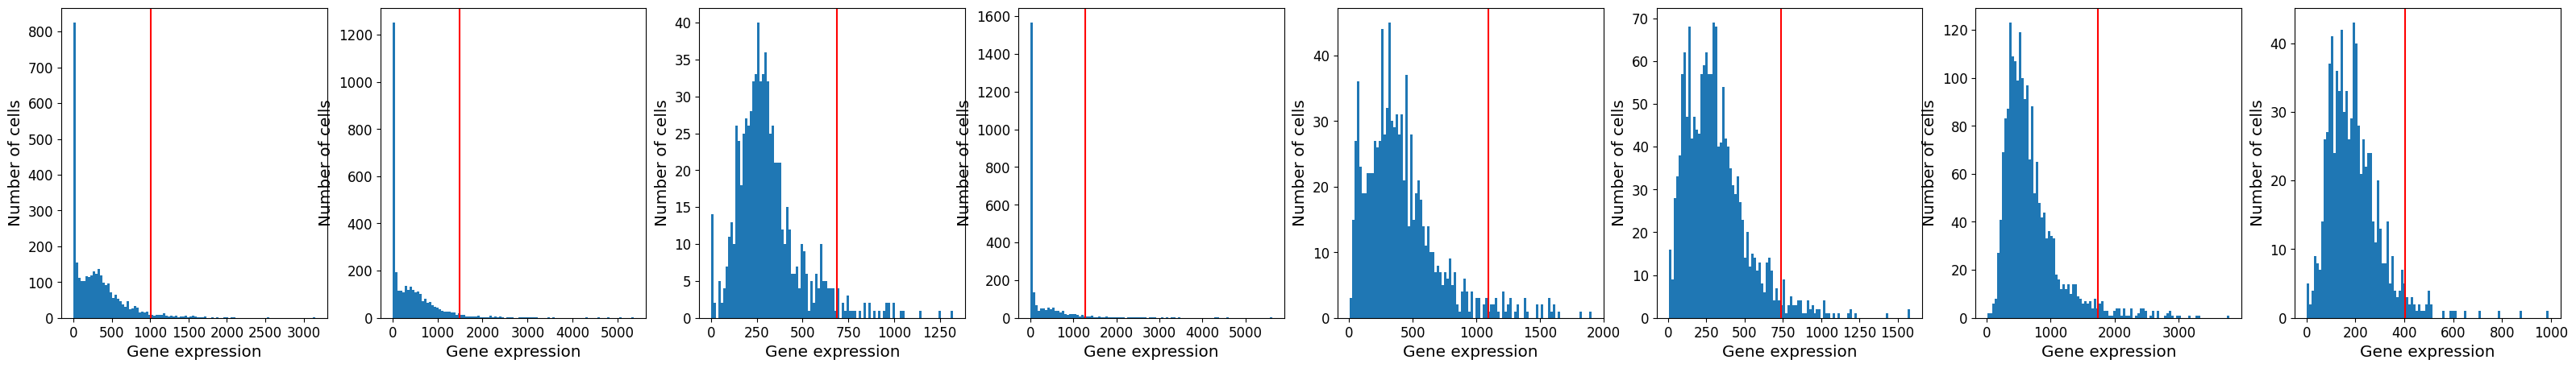

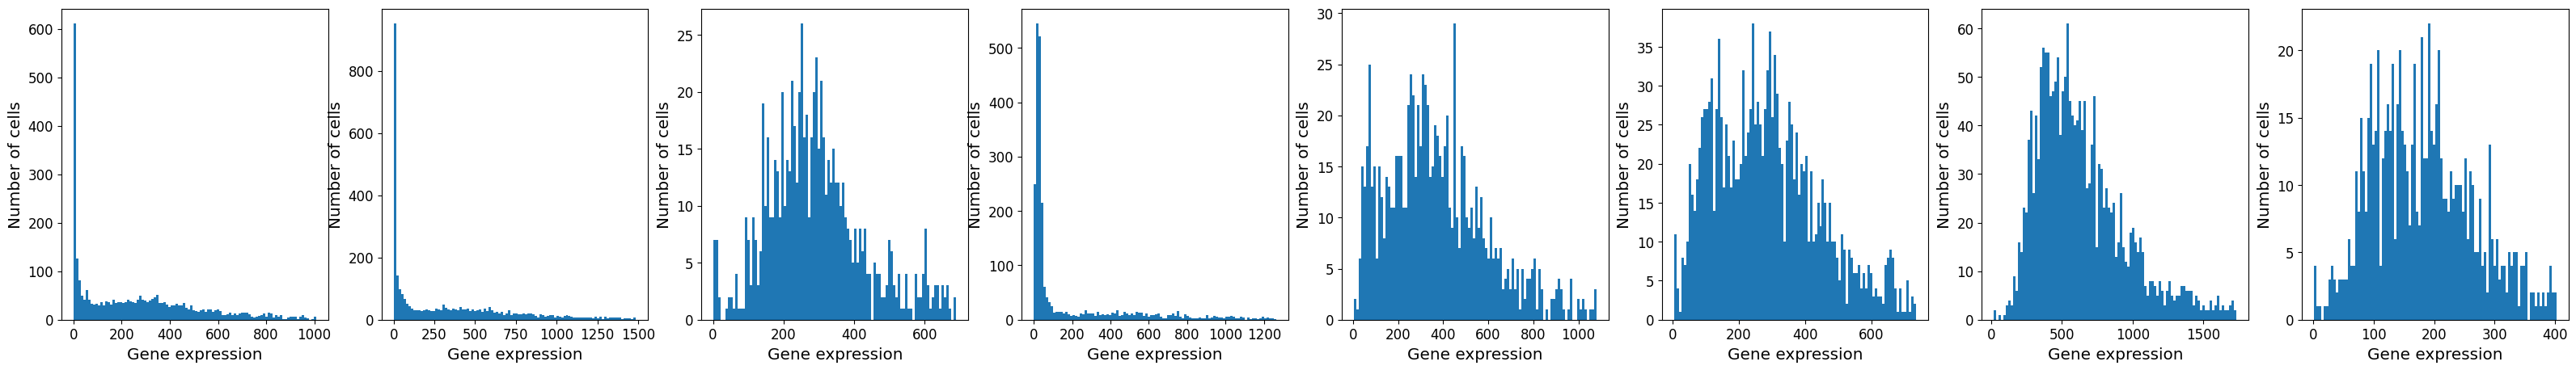

In [23]:
mt_genes = list(
    set.intersection(
        *[
            set(s)
            for s in [
                [g for g in dat.columns if g.startswith("MT-")]
                for dat in data_list_filt.values()
            ]
        ]
    )
)

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), ax in zip(data_list_filt.items(), axes):
    scprep.plot.plot_gene_set_expression(dat, genes=mt_genes, percentile=96, ax=ax)

for s, dat in data_list_filt.items():
    print(f"before mito filt{s}: {dat.shape}")
    dat = scprep.filter.filter_gene_set_expression(
        data=dat, genes=mt_genes, percentile=96, keep_cells="below"
    )
    print(f"after mito filt {s}: {dat.shape}")
    data_list_filt[s] = dat

_, axes = plt.subplots(1, len(data_list_filt), figsize=(5 * len(data_list_filt), 5))
for (s, dat), ax in zip(data_list_filt.items(), axes):
    scprep.plot.plot_gene_set_expression(dat, genes=mt_genes, ax=ax)

In [ ]:
# read paper's meta
import pandas as pd
from anndata import AnnData

adata_list = []
for s, dat in data_list_filt.items():
    adata = AnnData(dat)
    adata.obs["sample_labels"] = s
    adata.obs["barcode"] = adata.obs.index
    if s in ["GSM4300502_gastruloid1_44h", "GSM4300503_gastruloid2_44h"]:
        adata.obs["stage"] = s.split("_")[-1]
        if s == "GSM4300502_gastruloid1_44h":
            adata.obs["Time and replicate"] = "44h Gastruloid Rep 1"
        elif s == "GSM4300503_gastruloid2_44h":
            adata.obs["Time and replicate"] = "44h Gastruloid Rep 2"
    else:
        adata.obs["Time and replicate"] = (
            s.split("_")[-2] + " Gastruloid Rep " + s.split("_")[-1]
        )
        adata.obs["stage"] = s.split("_")[-2]
    rep_id = [s[-1] for s in adata.obs["sample_labels"].str.split("_")]
    adata.obs.index = pd.Index(
        adata.obs.index.str.cat(adata.obs["sample_labels"], sep="_")
    )
    adata_list.append(adata)
adata = sc.concat(adata_list)
# merge meta
meta = pd.read_csv(data_path / "GSE169074_gastruloid.all.time.metadata.csv.gz")
meta["barcode"] = [s[0] for s in meta["Cell ID"].str.split("_")]
meta = adata.obs.merge(meta, how="left", on=["barcode", "Time and replicate"])
meta.index = adata.obs.index
adata.obs = meta
# the name is minn_gastruloid_0-24h_qc_20260213.h5ad (also contains 44h data)
mic.io.upload_minn_adata(adata, processing_stage="qc")

Saving AnnData to /tmp/tmpviv1loa3/minn_gastruloid_0-24h_qc_20260213.h5ad
Uploading to s3://stan-sequencing-data/processed-active/Minn-micropattern-0-24h/minn_gastruloid_0-24h_qc_20260213.h5ad


100%|██████████| 1/1 [00:17<00:00, 17.88s/it]

Upload complete: s3://stan-sequencing-data/processed-active/Minn-micropattern-0-24h/minn_gastruloid_0-24h_qc_20260213.h5ad


In [34]:
adata

AnnData object with n_obs × n_vars = 14520 × 12772
    obs: 'sample_labels', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'

# Integration

In [8]:
mic.io.fetch_minn(cwd, type="adata", stage="qc")

100%|██████████| 1/1 [03:09<00:00, 189.15s/it]


In [9]:
mic.io.fetch_heemskerk(cwd)

100%|██████████| 1/1 [12:16<00:00, 736.75s/it]


100%|██████████| 1/1 [00:01<00:00,  1.22s/it]


100%|██████████| 1/1 [00:43<00:00, 43.00s/it]


100%|██████████| 1/1 [00:47<00:00, 47.91s/it]


In [27]:
adata_minn = mic.io.MINN_ADATA_LIST["qc"]
adata_heemskerk_D2_D10 = mic.io.HEEMSKERK_ADATA_D2_D10["adata"]
meta_heemskerk_D2_D10 = mic.io.HEEMSKERK_ADATA_D2_D10["meta"]
adata_heemskerk_42h = mic.io.HEEMSKERK_ADATA_42H
minn_data_path = cwd / "minn_data"
heemskerk_data_path = cwd / "heemskerk_data"
adata_minn = sc.read_h5ad(minn_data_path / adata_minn)
adata_heemskerk_d2_d10 = sc.read_h5ad(heemskerk_data_path / adata_heemskerk_D2_D10)
meta_heemskerk_d2_d10 = pd.read_csv(heemskerk_data_path / meta_heemskerk_D2_D10, index_col=0)
adata_heemskerk_d2_d10.obs = meta_heemskerk_d2_d10.loc[adata_heemskerk_d2_d10.obs.index]
adata_heemskerk_42h_list = []
for s, f in adata_heemskerk_42h.items():
    adata_tmp = sc.read_h5ad(heemskerk_data_path / f)
    adata_tmp.obs["sample_labels"] = adata_tmp.obs["sample_labels"].str.cat(["_42h"] * adata_tmp.shape[0])
    adata_heemskerk_42h_list.append(adata_tmp)
adata_heemskerk_42h = sc.concat(adata_heemskerk_42h_list)

print(adata_minn)
print(adata_heemskerk_d2_d10)
print(adata_heemskerk_42h)
print(
    f"{len(set.intersection(set(adata_heemskerk_d2_d10.var_names), set(adata_heemskerk_42h.var_names), set(adata_minn.var_names)))} genes in common"
)
adata_heemskerk_d2_d10.obs["source"] = "heemskerk"
adata_heemskerk_42h.obs["source"] = "heemskerk"
adata_minn.obs["source"] = "minn"
adata = sc.concat([adata_heemskerk_d2_d10, adata_heemskerk_42h, adata_minn], join="outer")
print(adata)
adata.obs = pd.concat([adata_heemskerk_d2_d10.obs, adata_heemskerk_42h.obs, adata_minn.obs])

AnnData object with n_obs × n_vars = 14520 × 12772
    obs: 'sample_labels', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'
AnnData object with n_obs × n_vars = 62402 × 16519
    obs: 'sample_labels', 'leiden_sub', 'leiden_sub_sub2', 'branch_joint', 'dpt_pseudotime', 'leiden_sub_colors', 'leiden_sub_sub2_colors', 'umap_old_48-96h_x', 'umap_old_48-96h_y', 'umap_new_D4-10_x', 'umap_new_D4-10_y'
AnnData object with n_obs × n_vars = 10815 × 20685
    obs: 'sample_labels'
11230 genes in common
AnnData object with n_obs × n_vars = 87737 × 23145
    obs: 'sample_labels', 'leiden_sub', 'leiden_sub_sub2', 'branch_joint', 'dpt_pseudotime', 'leiden_sub_colors', 'leiden_sub_sub2_colors', 'umap_old_48-96h_x', 'umap_old_48-96h_y', 'umap_new_D4-10_x', 'umap_new_D4-10_y', 'source', 'barcode', 'Time and replicate', 'stage', 'Cell ID', 'Cell type'


In [28]:
adata.obs["sample_labels"].value_counts()

,count
sample_labels,
72h-2,11505
48h-2,9850
bc_2,8702
96h-2,8481
72h-1,6166
48h-1,5927
BMP4_42h,5488
2020-FC-9000_42h,5327
96h-1,4579


In [29]:
cc_genes = mic.io.read_cc_list(cwd)

100%|██████████| 1/1 [00:00<00:00,  8.12it/s]


In [30]:
mic.utils.normalize_and_select_hvg(adata, n_top_genes=10000)

2026-02-14 17:21:36.574 | INFO     | micropattern.utils:normalize_and_select_hvg:56 - Copying X to counts layer before normalization
2026-02-14 17:21:37.569 | INFO     | micropattern.utils:normalize_and_select_hvg:60 - Normalizing to target sum 10000.0 and applying log1p transformation
2026-02-14 17:21:47.239 | INFO     | micropattern.utils:normalize_and_select_hvg:82 - Saving X to raw before computing HVG
2026-02-14 17:21:47.242 | INFO     | micropattern.utils:normalize_and_select_hvg:86 - Computing top 10000 highly variable genes (seurat_v3)


In [41]:
# make sure core tfs are there
core_tfs = "^SOX|NANOG|^TBXT|EOMES|TFAP2|GATA|ISL|PRDM|POU5|FOXC|FOXF"
adata.var_names[adata.var_names.str.contains(core_tfs)]

Index(['EOMES (ENSG00000163508)', 'FOXC1 (ENSG00000054598)',
       'FOXC2 (ENSG00000176692)', 'FOXF1 (ENSG00000103241)',
       'FOXF2 (ENSG00000137273)', 'GATA1 (ENSG00000102145)',
       'GATA2 (ENSG00000179348)', 'GATA2-AS1 (ENSG00000244300)',
       'GATA3 (ENSG00000107485)', 'GATA3-AS1 (ENSG00000197308)',
       'GATA4 (ENSG00000136574)', 'GATA5 (ENSG00000130700)',
       'GATA6 (ENSG00000141448)', 'GATA6-AS1 (ENSG00000266010)',
       'ISL1 (ENSG00000016082)', 'ISL2 (ENSG00000159556)',
       'ISLR2 (ENSG00000167178)', 'NANOG (ENSG00000111704)',
       'NANOGP8 (ENSG00000255192)', 'POU5F1 (ENSG00000204531)',
       'POU5F1B (ENSG00000212993)', 'POU5F2 (ENSG00000248483)',
       'PRDM1 (ENSG00000057657)', 'PRDM14 (ENSG00000147596)',
       'PRDM5 (ENSG00000138738)', 'PRDM6 (ENSG00000061455)',
       'PRDM8 (ENSG00000152784)', 'PRDM9 (ENSG00000164256)',
       'SOX1 (ENSG00000182968)', 'SOX11 (ENSG00000176887)',
       'SOX13 (ENSG00000143842)', 'SOX14 (ENSG00000168875)',
       '

In [ ]:
filter1 = adata.var["highly_variable_nbatches"] >= 2 # each stage has 2 replicates so do 2 here
glist_sorted = adata.var["variances_norm"][filter1].sort_values(ascending=False).index
adata.var["top500"] = adata.var.index.isin(glist_sorted[:500])
adata.var["top750"] = adata.var.index.isin(glist_sorted[:750])
adata.var["top1000"] = adata.var.index.isin(glist_sorted[:1000])
adata.var["top1500"] = adata.var.index.isin(glist_sorted[:1500])
adata.var["top2000"] = adata.var.index.isin(glist_sorted[:2000])
adata.var[adata.var["top500"]].index[adata.var[adata.var["top500"]].index.str.contains(core_tfs)]

Index(['EOMES (ENSG00000163508)', 'FOXC1 (ENSG00000054598)',
       'GATA2 (ENSG00000179348)', 'GATA3 (ENSG00000107485)',
       'GATA6 (ENSG00000141448)', 'ISL1 (ENSG00000016082)',
       'PRDM1 (ENSG00000057657)', 'SOX17 (ENSG00000164736)',
       'SOX2 (ENSG00000181449)', 'SOX7 (ENSG00000171056)',
       'TBXT (ENSG00000164458)', 'TFAP2A (ENSG00000137203)',
       'TFAP2C (ENSG00000087510)'],
      dtype='object')

In [79]:
# save hvg intermediate for cloud jobs
mic.io.upload_adata(
    adata,
    s3_path="stan-sequencing-data/processed-active/Minn-Heemskerk-micropattern",
    filename="adata_minn_heemskerk_micropattern_0-10d_hvg.h5ad"
)

Saving AnnData to /tmp/tmp71amam2v/adata_minn_heemskerk_micropattern_0-10d_hvg.h5ad
Uploading to s3://stan-sequencing-data/processed-active/Minn-Heemskerk-micropattern/adata_minn_heemskerk_micropattern_0-10d_hvg.h5ad


100%|██████████| 1/1 [04:07<00:00, 247.96s/it]

Upload complete: s3://stan-sequencing-data/processed-active/Minn-Heemskerk-micropattern/adata_minn_heemskerk_micropattern_0-10d_hvg.h5ad


In [44]:
cc_genes_all = [g for gl in cc_genes.values() for g in gl]
cc_genes_all = [
    g
    for g in adata.var_names
    if g.split()[0] in cc_genes_all and g not in adata.obs.columns
]
print(f"Insert {len(cc_genes_all)} cc genes into obs")
adata.obs = pd.concat([adata.obs, adata[:, cc_genes_all].to_df()], axis=1)

Insert 41 cc genes into obs


In [ ]:
mic.integration.integration(
    adata,
    run_name="minn_heemskerk_micropatern_0-10d_600hvg_40lv",
    categorical_covariates_keys=["source"],
    continuous_covariates_keys=cc_genes_all,
    n_latent=60,
    lr=1e-5,
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: Th

Training:   0%|          | 0/400 [00:00<?, ?it/s]

In [32]:
sc.set_figure_params(figsize=(5, 5))

In [36]:
sc.pp.neighbors(adata, n_neighbors=25, use_rep="X_scvi", random_state=1)

In [37]:
sc.tl.umap(adata, min_dist=0.01, random_state=1)

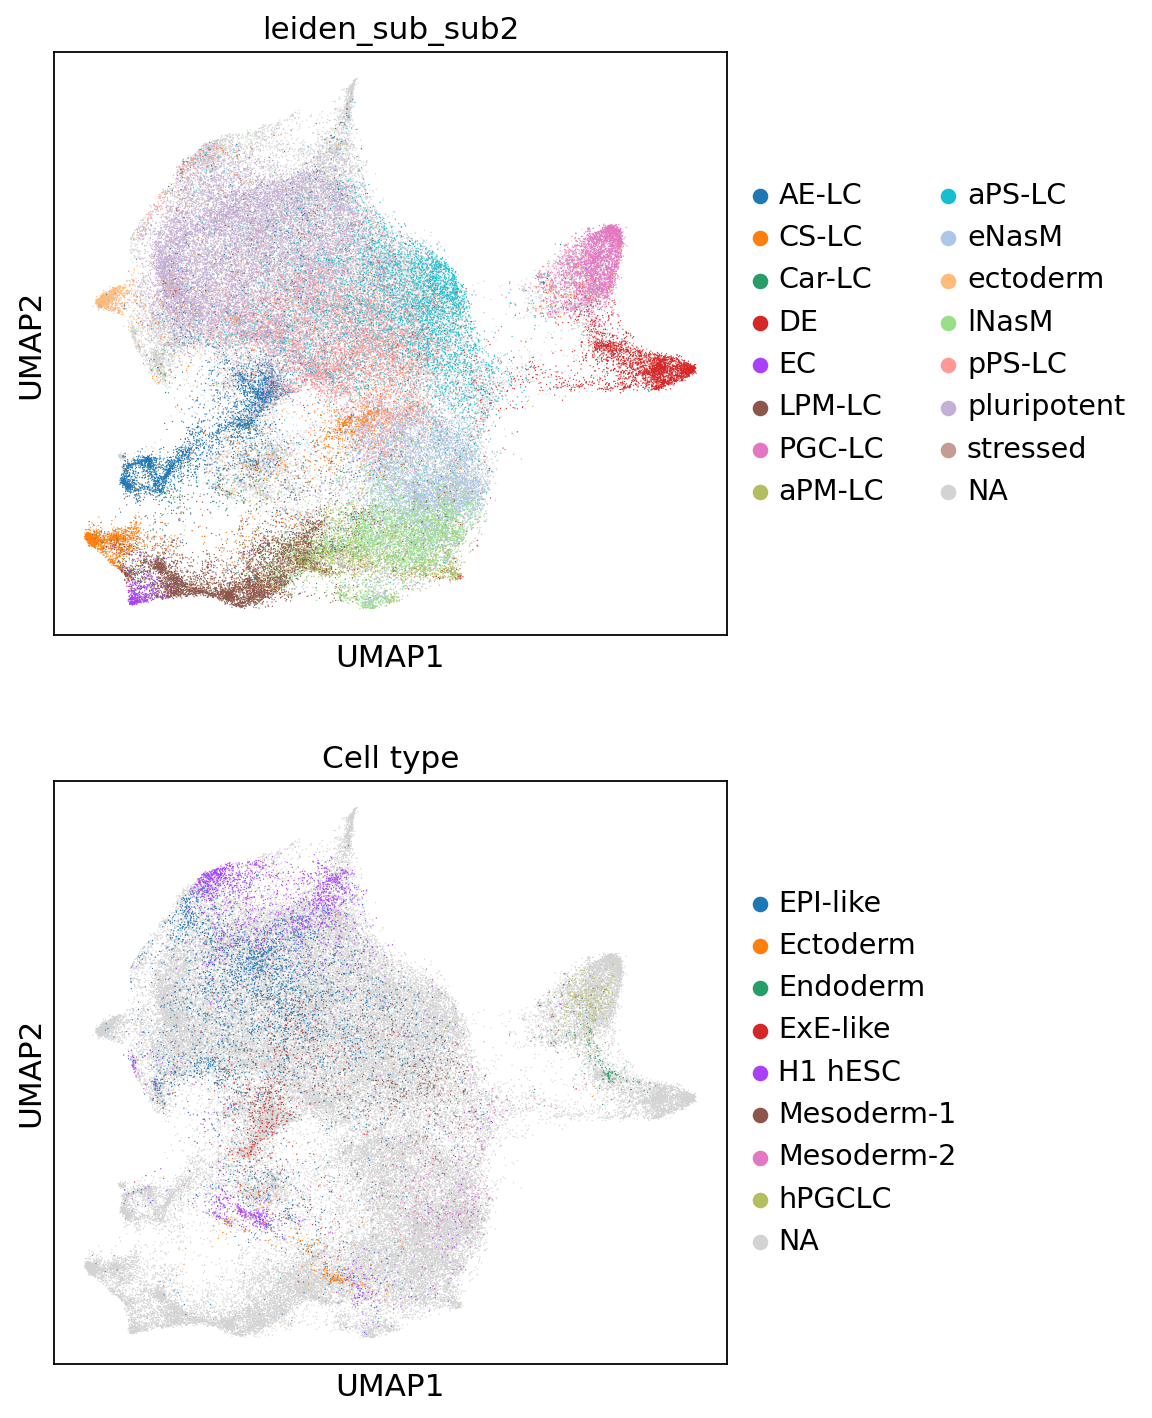

In [39]:
sc.pl.umap(adata, color=["leiden_sub_sub2", "Cell type"], ncols=1)

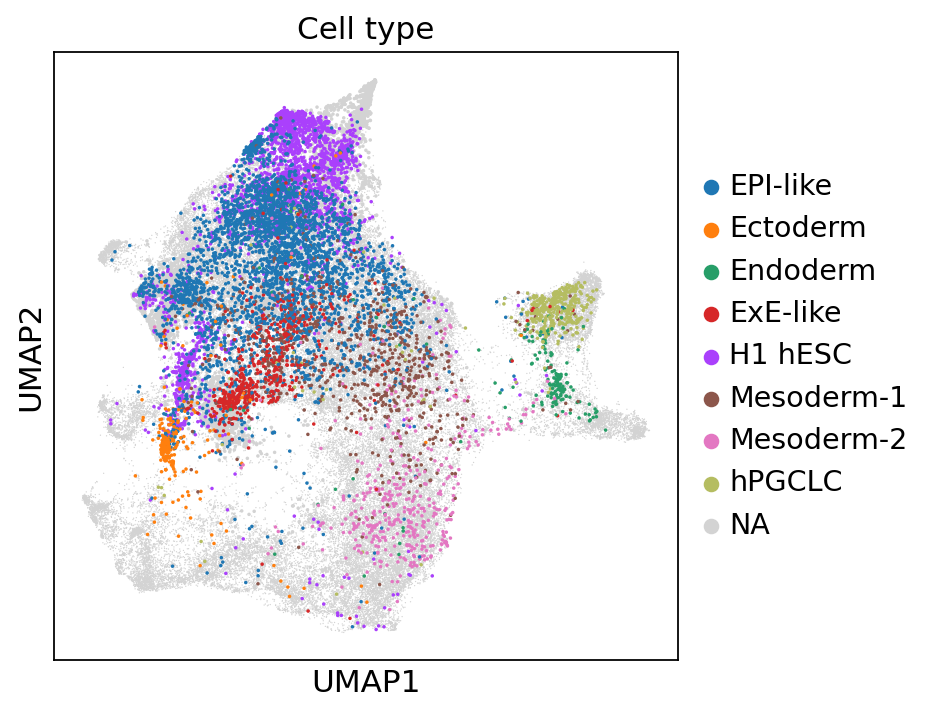

In [26]:
ax = sc.pl.umap(adata, show=False)
sc.pl.umap(
    adata[adata.obs["sample_labels"].str.contains("GSM")],
    color="Cell type",
    ax=ax,
    size=10,
)